In [1]:
# Imports
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import sys
sys.path.append('..')

from src.datasets import NIHChestXrayDataset

In [2]:
# Load Dataframe
data_dir = "/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH_Chest_Xray_Dataset/datasets/nih-chest-xrays/data/versions/3"
df = pd.read_csv(os.path.join(data_dir, "df_test.csv"))

In [3]:
# Repalce image paths 
df['Image Path'] = df['Image Path'].replace(to_replace="/usr/app/data", value= data_dir, regex=True)

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [5]:
# Columns of Dataframe
df.columns

Index(['image_index', 'finding_labels', 'follow_up_number', 'patient_id',
       'patient_age', 'patient_gender', 'view_position',
       'original_image_width', 'original_image_height',
       'original_image_pixel_spacing_x', 'original_image_pixel_spacing_y',
       'image_path', 'fibrosis', 'atelectasis', 'nodule', 'no_finding',
       'edema', 'hernia', 'consolidation', 'pneumothorax', 'infiltration',
       'pneumonia', 'pleural_thickening', 'emphysema', 'cardiomegaly', 'mass',
       'effusion'],
      dtype='object')

In [6]:
df['finding_labels']

0                     Hernia
1                     Hernia
2                     Hernia
3        Hernia|Infiltration
4                     Hernia
                ...         
25591             No Finding
25592             No Finding
25593             No Finding
25594             No Finding
25595             No Finding
Name: finding_labels, Length: 25596, dtype: object

In [7]:
# Identifying Multiple Labels
df['no_pipe'] = ~df['finding_labels'].str.contains('|', regex=False, na=False)

In [8]:
df['multi_labels'] = df['finding_labels'].str.get_dummies(sep="|").values.tolist()

In [9]:
class_idx_dict = {
    label.lower().replace(' ', '_'): idx for idx, label in enumerate(df['finding_labels'].str.get_dummies(sep="|").columns)
    }

In [10]:
class_idx_dict

{'atelectasis': 0,
 'cardiomegaly': 1,
 'consolidation': 2,
 'edema': 3,
 'effusion': 4,
 'emphysema': 5,
 'fibrosis': 6,
 'hernia': 7,
 'infiltration': 8,
 'mass': 9,
 'no_finding': 10,
 'nodule': 11,
 'pleural_thickening': 12,
 'pneumonia': 13,
 'pneumothorax': 14}

In [11]:
df['multi_labels']

0        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
1        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
2        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
3        [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0]
4        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
                             ...                      
25591    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
25592    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
25593    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
25594    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
25595    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Name: multi_labels, Length: 25596, dtype: object

In [12]:
# Create separate Dataframe for each disease with only single disease positive samples
df_dict = {}
for n in class_idx_dict.keys():
    exec(f"df_dict['{n.lower().replace(' ', '_')}'] = df[(df['{n}'] == 1) & (df['no_pipe'] == True)].reset_index(drop=True)")

In [13]:
# Keys of the Dataframe dictionary
df_dict.keys()

dict_keys(['atelectasis', 'cardiomegaly', 'consolidation', 'edema', 'effusion', 'emphysema', 'fibrosis', 'hernia', 'infiltration', 'mass', 'no_finding', 'nodule', 'pleural_thickening', 'pneumonia', 'pneumothorax'])

In [14]:
dataset = NIHChestXrayDataset(df, transform=None)

In [15]:
dl = DataLoader(dataset, batch_size=1 , shuffle=False, pin_memory=True)


In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [28]:
# Load Model
model = models.densenet161(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 15)
model.load_state_dict(torch.load('../results/Tutorial_29122025_00/checkpoint_max_metric.pt'))
model.to(device)
model.eval();

/home/jahmed/miniconda3/envs/trackr/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jahmed/miniconda3/envs/trackr/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
# Grad-CAM Implementation
def grad_cam(model, img, target_class):
    model.eval()
    features, gradients = [], []

    def forward_hook(module, input, output):
        features.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    layer = model.features.denseblock4.denselayer16.conv2
    layer.register_forward_hook(forward_hook)
    layer.register_backward_hook(backward_hook)

    img = img.to(device)
    output = model(img)
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    fmap = features[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1,2))
    cam = np.zeros(fmap.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmap[i]
    cam = np.maximum(cam,0)
    cam = cv2.resize(cam, (224,224))
    return cam

In [46]:
results = {}

for disease_dict in df_dict:
    print(f"Processing disease: {disease_dict}")
    disease_df = df_dict[disease_dict]

    disease_dataset = NIHChestXrayDataset(disease_df, transform=None)
    disease_dl = DataLoader(disease_dataset, batch_size=1 , shuffle=False, pin_memory=True)

    target_class = class_idx_dict[disease_dict]
    print(f"Target class index: {target_class}")

    mean = np.zeros((224,224), dtype=np.float32)
    M2 = np.zeros((224, 224), dtype=np.float32)
    n = 0

    for idx, (img, _) in enumerate(disease_dl):
        cam = grad_cam(model, img, target_class)

        n += 1

        delta = cam - mean
        mean += delta / n
        
        delta2 = cam - mean
        M2 += delta * delta2

        if n == 20:
            break

    var = M2 / (n - 1)
    std = np.sqrt(var)

    mean_vis = (mean - mean.min()) / (mean.max() - mean.min() + 1e-8)
    std_vis = (std - std.min()) / (std.max() - std.min() + 1e-8)

    results[disease_dict] = {
        "img": img.squeeze().cpu().numpy(),
        "mean": mean,
        "var": var,
        "std": std,
        "mean_vis": mean_vis,
        "std_vis": std_vis,
        "n_samples": n,
    }

Processing disease: atelectasis
Target class index: 0


/home/jahmed/miniconda3/envs/trackr/lib/python3.10/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Processing disease: cardiomegaly
Target class index: 1
Processing disease: consolidation
Target class index: 2
Processing disease: edema
Target class index: 3
Processing disease: effusion
Target class index: 4
Processing disease: emphysema
Target class index: 5
Processing disease: fibrosis
Target class index: 6
Processing disease: hernia
Target class index: 7
Processing disease: infiltration
Target class index: 8
Processing disease: mass
Target class index: 9
Processing disease: no_finding
Target class index: 10
Processing disease: nodule
Target class index: 11
Processing disease: pleural_thickening
Target class index: 12
Processing disease: pneumonia
Target class index: 13
Processing disease: pneumothorax
Target class index: 14


In [44]:
def plot_gradcam_overview(results, cmap="jet"):
    diseases = list(results.keys())
    num_classes = len(diseases)

    fig, axes = plt.subplots(num_classes, 3, figsize=(10, 3 * num_classes))

    for i, disease in enumerate(diseases):
        mean_cam = results[disease]["mean_vis"]
        std_cam = results[disease]["std_vis"]
        n = results[disease]["n_samples"]

        axes[i, 0].imshow(results[disease]["img"][0], cmap='gray')
        axes[i, 0].imshow(mean_cam, cmap=cmap, alpha=0.4)
        axes[i, 0].set_title(f"{disease}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mean_cam, cmap=cmap)
        axes[i, 1].set_title(f"{disease} — Mean (n={n})")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(std_cam, cmap=cmap)
        axes[i, 2].set_title("Std")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

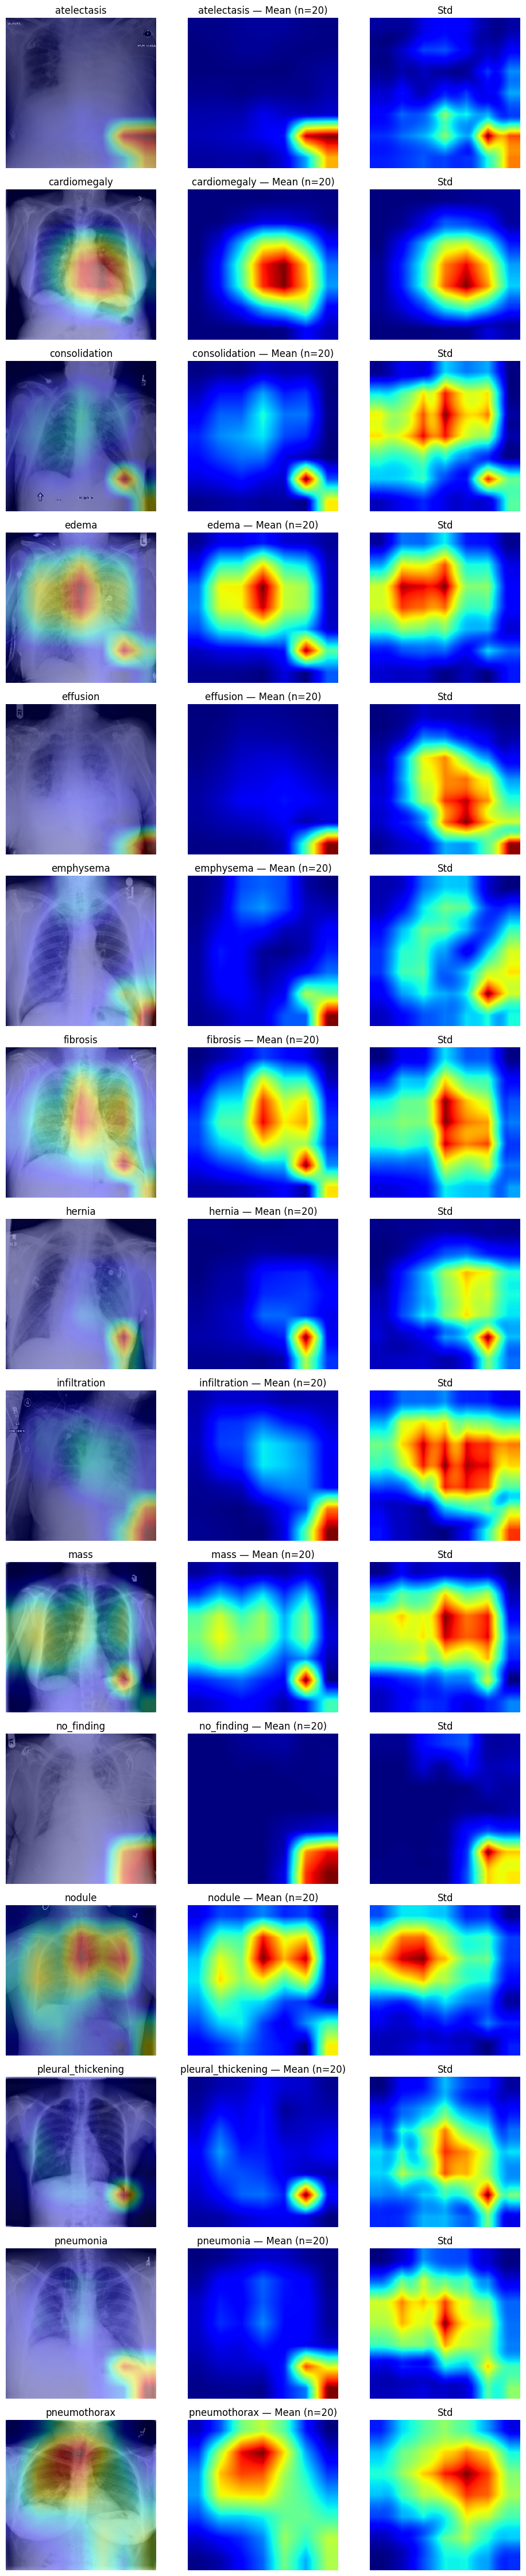

In [47]:
plot_gradcam_overview(results)